In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problem_solver.deformed_gaussian.unrolled.gradient_descent import GradientDescentUnrolledSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.nn.module.polynomial_activation import PolynomialActivation
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.polynomial_parity import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

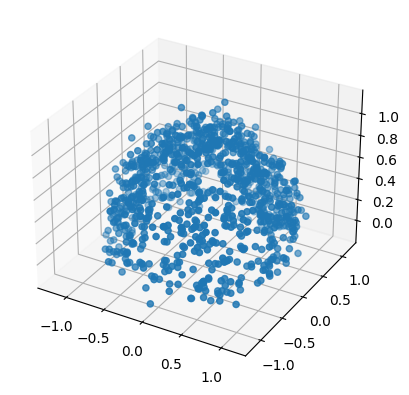

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
    def adjoint_forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for _ in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=True))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=True))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=1))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=True))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=True))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Create the feed forward model
def create_feed_forward_model(in_dim, out_dim, n_layers, hidden_dim=16):
    layers = []
    layers.append(nn.Linear(in_dim, hidden_dim))
    layers.append(nn.ReLU())
    for _ in range(n_layers - 2):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(hidden_dim, out_dim))
    
    return nn.Sequential(*layers)


In [6]:
# Trivial feedforward model

In [7]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 4
flow = create_flow_model(dim, n_flows, 2)
phi = NFlowVectorDiffeomorphism(dim, flow)

l2_weight = 1.
num_steps = 8

n_layers = 4
Gamma = create_feed_forward_model(2 * dim, dim, n_layers)

model = GradientDescentUnrolledSolver(forward, phi, l2_weight, num_steps, Gamma).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [9]:
# Train the model
n_epochs = 100
train(model, train_loader, optimizer, n_epochs)

Epoch 1/100, Loss: 29.3245
Epoch 2/100, Loss: 26.4318
Epoch 3/100, Loss: 23.9053
Epoch 4/100, Loss: 21.6970
Epoch 5/100, Loss: 19.7354
Epoch 6/100, Loss: 17.9185
Epoch 7/100, Loss: 16.1105
Epoch 8/100, Loss: 14.2172
Epoch 9/100, Loss: 12.3789
Epoch 10/100, Loss: 10.7588
Epoch 11/100, Loss: 9.3362
Epoch 12/100, Loss: 8.1345
Epoch 13/100, Loss: 7.1577
Epoch 14/100, Loss: 6.3657
Epoch 15/100, Loss: 5.7045
Epoch 16/100, Loss: 5.1408
Epoch 17/100, Loss: 4.6474
Epoch 18/100, Loss: 4.1987
Epoch 19/100, Loss: 3.7755
Epoch 20/100, Loss: 3.3828
Epoch 21/100, Loss: 3.0264
Epoch 22/100, Loss: 2.6868
Epoch 23/100, Loss: 2.3545
Epoch 24/100, Loss: 2.0478
Epoch 25/100, Loss: 1.7892
Epoch 26/100, Loss: 1.5835
Epoch 27/100, Loss: 1.4139
Epoch 28/100, Loss: 1.2729
Epoch 29/100, Loss: 1.1566
Epoch 30/100, Loss: 1.0562
Epoch 31/100, Loss: 0.9690
Epoch 32/100, Loss: 0.8990
Epoch 33/100, Loss: 0.8417
Epoch 34/100, Loss: 0.7957
Epoch 35/100, Loss: 0.7607
Epoch 36/100, Loss: 0.7343
Epoch 37/100, Loss: 0.7131


### Evaluating Geometry ###

In [10]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [11]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [12]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

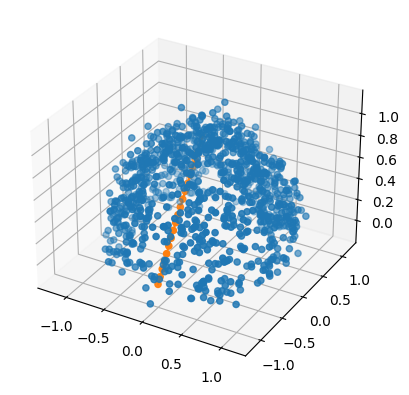

In [13]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [14]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([ 0.0316, -0.0057,  0.4825], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


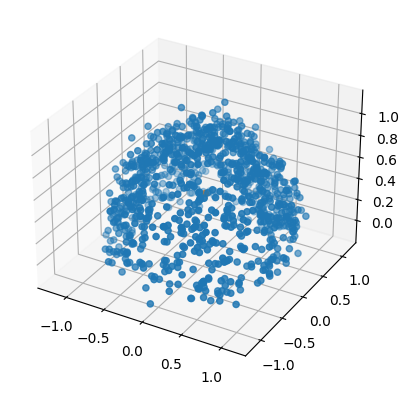

In [15]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [16]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [17]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


In [18]:
# compute approximations
approximations = l2_pga_solver.exp_x_Xi[2]

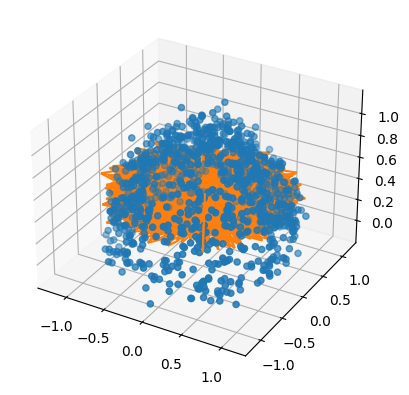

In [19]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


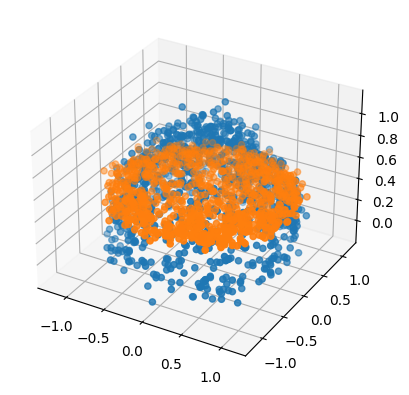

In [20]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [21]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0914, grad_fn=<SumBackward0>)
